# 🌤️ CORGIS Weather Time Series Forecasting
## ANN, RNN, LSTM, GRU - Regression Task
**Dataset:** Weather Dataset (CORGIS) - US weather stations data

This notebook forecasts average temperature using deep learning models.

---
## 1. 📦 Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.20.0


---
## 2. 📊 Dataset Understanding

DATASET OVERVIEW
Shape: (16743, 14)

Columns (14):
['Data.Precipitation', 'Date.Full', 'Date.Month', 'Date.Week of', 'Date.Year', 'Station.City', 'Station.Code', 'Station.Location', 'Station.State', 'Data.Temperature.Avg Temp', 'Data.Temperature.Max Temp', 'Data.Temperature.Min Temp', 'Data.Wind.Direction', 'Data.Wind.Speed']

Data Types:
Data.Precipitation           float64
Date.Full                     object
Date.Month                     int64
Date.Week of                   int64
Date.Year                      int64
Station.City                  object
Station.Code                  object
Station.Location              object
Station.State                 object
Data.Temperature.Avg Temp      int64
Data.Temperature.Max Temp      int64
Data.Temperature.Min Temp      int64
Data.Wind.Direction            int64
Data.Wind.Speed              float64
dtype: object

Basic Statistics:
       Data.Precipitation    Date.Month  Date.Week of     Date.Year  \
count        16743.000000  16743.0000

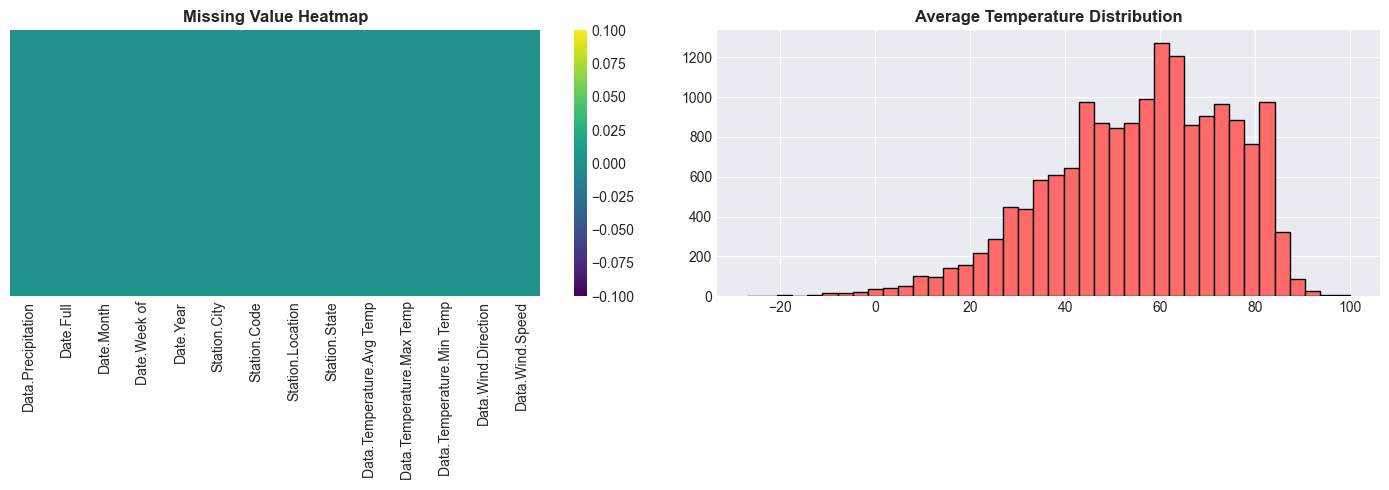

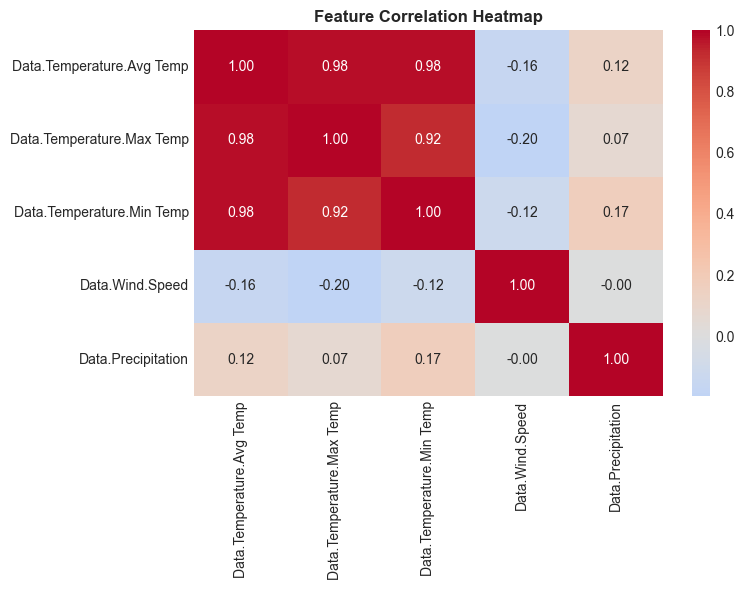

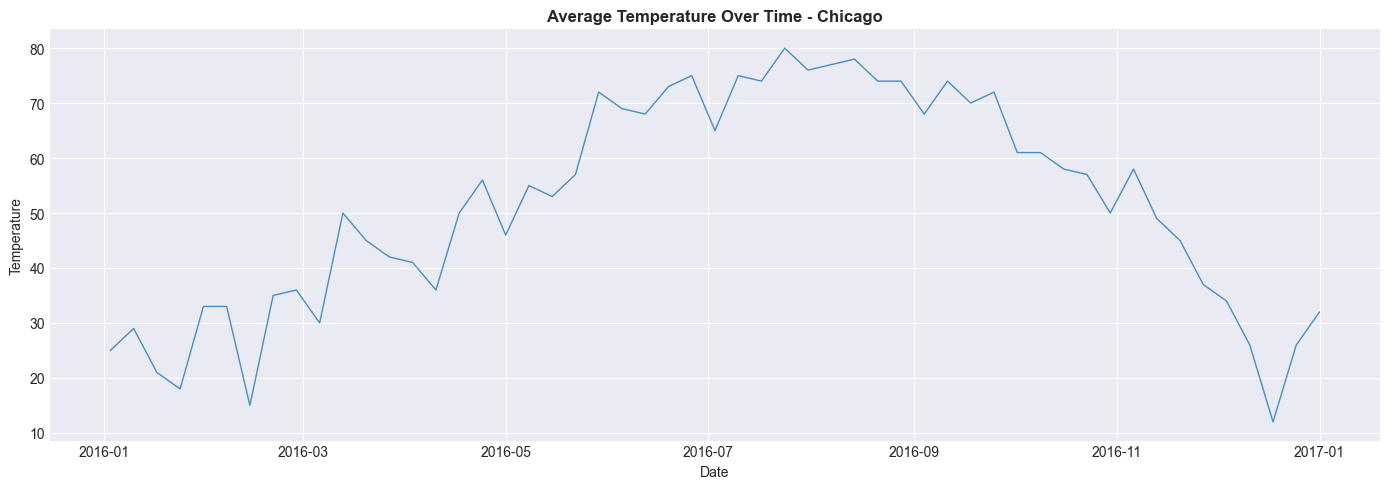

In [2]:

df = pd.read_csv('weather.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):\n{list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"\nUnique stations: {df['Station.City'].nunique()}")
print(f"Date range: {df['Date.Full'].min()} to {df['Date.Full'].max()}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Value Heatmap', fontweight='bold')

df['Data.Temperature.Avg Temp'].hist(bins=40, ax=axes[1], color='#FF6B6B', edgecolor='black')
axes[1].set_title('Average Temperature Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('corgis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_cols = ['Data.Temperature.Avg Temp', 'Data.Temperature.Max Temp',
             'Data.Temperature.Min Temp', 'Data.Wind.Speed', 'Data.Precipitation']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('corgis_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Time series for a specific city
city = 'Chicago'
city_df = df[df['Station.City'] == city].sort_values('Date.Full')
if len(city_df) > 0:
    plt.figure(figsize=(14, 5))
    plt.plot(pd.to_datetime(city_df['Date.Full']), city_df['Data.Temperature.Avg Temp'], 
             linewidth=1, alpha=0.8)
    plt.title(f'Average Temperature Over Time - {city}', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.tight_layout()
    plt.savefig('corgis_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 3. 🔧 Preprocessing

**Strategy:** We'll focus on a single city (Chicago) for clean time series modeling.
Using all stations would create a multi-variate, multi-location problem.

**Steps:**
- Filter to single city for clean temporal sequence
- Select numeric weather features
- MinMaxScaler for normalization
- Sliding window to create sequences

In [3]:

# Use Chicago data
city_data = df[df['Station.City'] == city].sort_values('Date.Full').reset_index(drop=True)

# Select features
feature_cols = ['Data.Temperature.Avg Temp', 'Data.Temperature.Max Temp',
                'Data.Temperature.Min Temp', 'Data.Wind.Speed', 'Data.Precipitation']
target_col = 'Data.Temperature.Avg Temp'

# Handle missing values
city_data[feature_cols] = city_data[feature_cols].apply(pd.to_numeric, errors='coerce')
city_data[feature_cols] = city_data[feature_cols].fillna(method='ffill').fillna(method='bfill')

data = city_data[feature_cols].values
print(f"City data shape: {data.shape}")

# Scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
WINDOW_SIZE = 10  # Smaller window since weekly data
target_idx = feature_cols.index(target_col)

def create_sequences(data, target_idx, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, target_idx, WINDOW_SIZE)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


City data shape: (53, 5)
X_train: (34, 10, 5), X_test: (9, 10, 5)


---
## 4. 🏗️ Model Building

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
EPOCHS = 100
BATCH = 16
n_features = X_train.shape[2]

### 4.1 ANN

In [6]:
# ANN
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_ann.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_ann.summary()
history_ann = model_ann.fit(X_train_flat, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 541ms/step - loss: 0.1182 - mae: 0.2808 - val_loss: 0.0141 - val_mae: 0.1078
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.1142 - mae: 0.2805 - val_loss: 0.0344 - val_mae: 0.1466
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.1235 - mae: 0.2936 - val_loss: 0.0707 - val_mae: 0.2381
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.1112 - mae: 0.2838 - val_loss: 0.0834 - val_mae: 0.2675
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.1807 - mae: 0.3258 - val_loss: 0.0600 - val_mae: 0.2209
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.0950 - mae: 0.2269 - val_loss: 0.0349 - val_mae: 0.1576
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.1146 - mae: 0.2543 - val_loss: 0.0144 - val_mae: 0.0891
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0865 - mae: 0.2453 - val_loss: 0.0116 - val_mae: 0.0943
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.118

### 4.2 RNN

In [7]:
# RNN
model_rnn = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_rnn = model_rnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 912ms/step - loss: 0.5111 - mae: 0.5792 - val_loss: 0.4298 - val_mae: 0.6373
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.2371 - mae: 0.4132 - val_loss: 0.0723 - val_mae: 0.2371
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - loss: 0.3082 - mae: 0.4286 - val_loss: 0.0214 - val_mae: 0.1246
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 0.2219 - mae: 0.4047 - val_loss: 0.2206 - val_mae: 0.4519
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.2639 - mae: 0.3489 - val_loss: 0.4548 - val_mae: 0.6607
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.2909 - mae: 0.4598 - val_loss: 0.4999 - val_mae: 0.6942
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.2220 - mae: 0.4040 - val_loss: 0.3552 - val_mae: 0.5810
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.2240 - mae: 0.3520 - val_loss: 0.2501 - val_mae: 0.4829
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.155

### 4.3 LSTM

In [8]:
# LSTM
model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_lstm = model_lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                              validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.6369 - mae: 0.7630 - val_loss: 0.3023 - val_mae: 0.5396
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.3366 - mae: 0.5549 - val_loss: 0.1095 - val_mae: 0.3157
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.1879 - mae: 0.3934 - val_loss: 0.0160 - val_mae: 0.1032
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.0673 - mae: 0.2248 - val_loss: 0.0314 - val_mae: 0.1534
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0167 - mae: 0.1013 - val_loss: 0.1227 - val_mae: 0.3398
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.0424 - mae: 0.1731 - val_loss: 0.1875 - val_mae: 0.4249
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0697 - mae: 0.2288 - val_loss: 0.1702 - val_mae: 0.4042
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.0546 - mae: 0.1974 - val_loss: 0.1178 - val_mae: 0.3330
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.0491 

### 4.4 GRU

In [9]:
# GRU
model_gru = Sequential([
    GRU(64, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_gru = model_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.6408 - mae: 0.7731 - val_loss: 0.3714 - val_mae: 0.6006
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - loss: 0.4179 - mae: 0.6216 - val_loss: 0.1586 - val_mae: 0.3869
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.2281 - mae: 0.4528 - val_loss: 0.0378 - val_mae: 0.1745
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 0.0885 - mae: 0.2661 - val_loss: 0.0074 - val_mae: 0.0804
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.0287 - mae: 0.1271 - val_loss: 0.0591 - val_mae: 0.2324
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.0279 - mae: 0.1335 - val_loss: 0.1562 - val_mae: 0.3895
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.0656 - mae: 0.2125 - val_loss: 0.2170 - val_mae: 0.4614
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0838 - mae: 0.2500 - val_loss: 0.1982 - val_mae: 0.4405
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.0864 

---
## 5. 📈 Training Curves

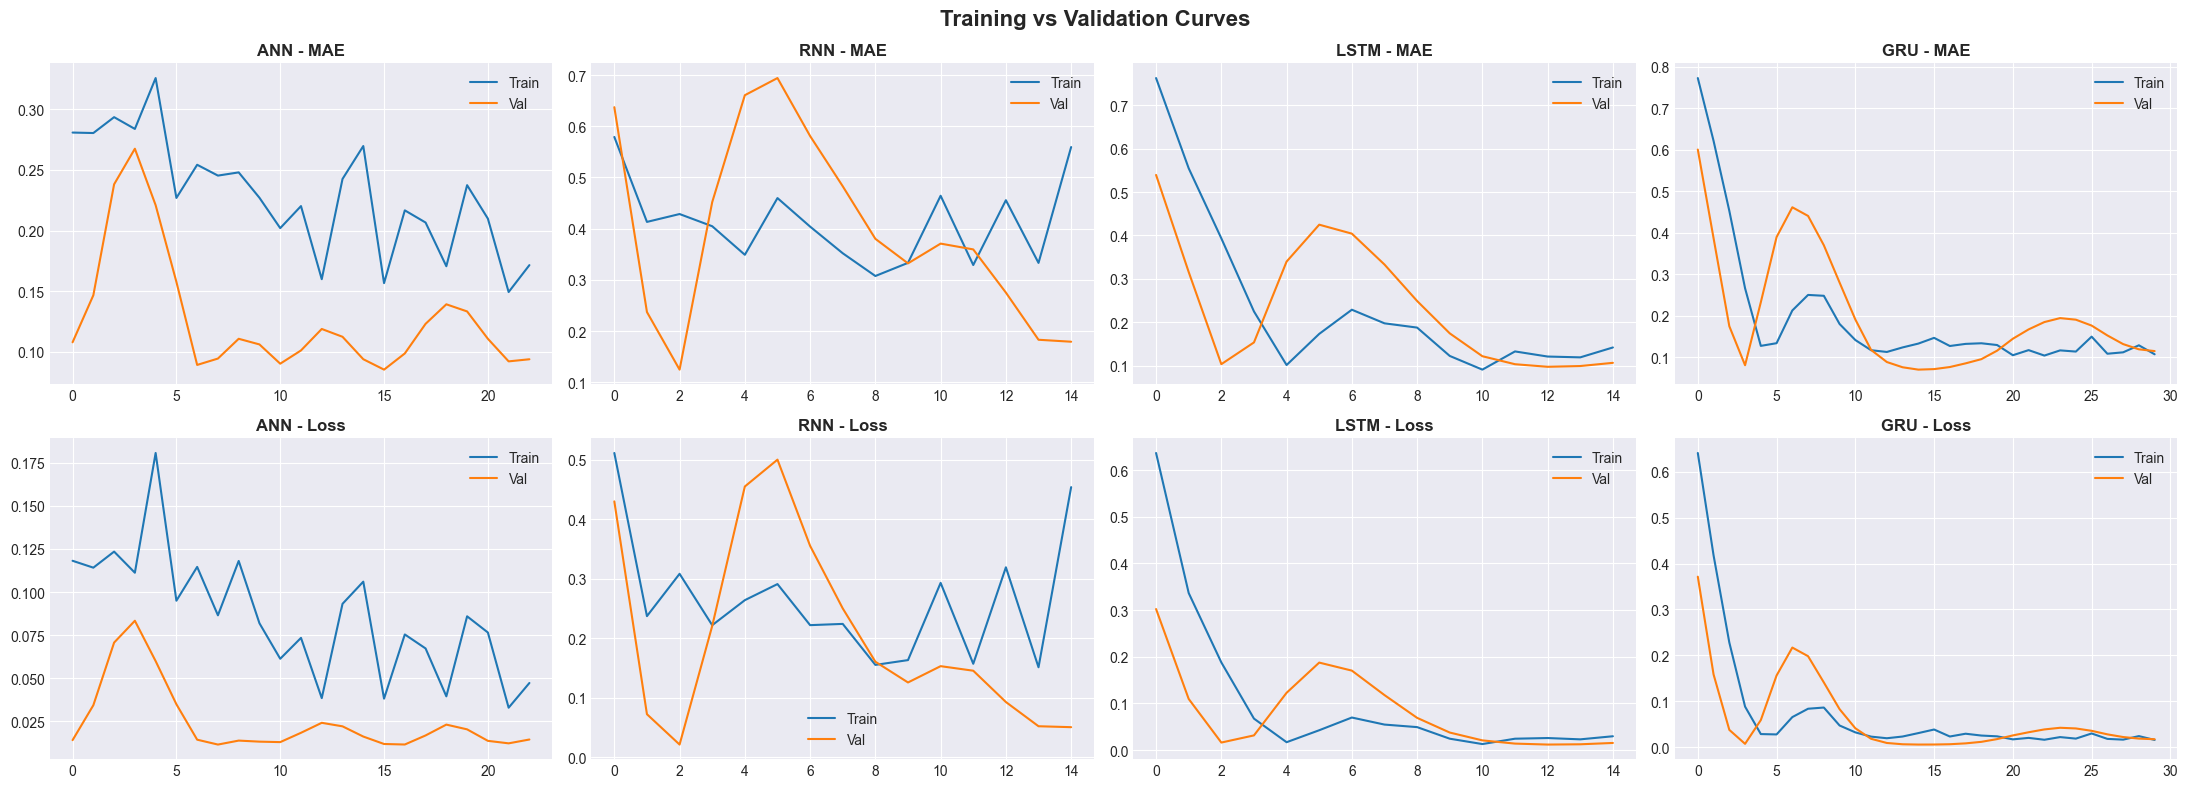

In [10]:

models_info = {'ANN': history_ann, 'RNN': history_rnn, 'LSTM': history_lstm, 'GRU': history_gru}

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
for i, (name, hist) in enumerate(models_info.items()):
    axes[0, i].plot(hist.history['mae'], label='Train')
    axes[0, i].plot(hist.history['val_mae'], label='Val')
    axes[0, i].set_title(f'{name} - MAE', fontweight='bold')
    axes[0, i].legend()
    axes[1, i].plot(hist.history['loss'], label='Train')
    axes[1, i].plot(hist.history['val_loss'], label='Val')
    axes[1, i].set_title(f'{name} - Loss', fontweight='bold')
    axes[1, i].legend()
plt.suptitle('Training vs Validation Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('corgis_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. 📋 Evaluation

In [11]:

def inverse_temp(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(feature_cols)))
    dummy[:, target_idx] = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

def evaluate_reg(model, X_te, y_te, name, flat=False):
    y_pred_s = model.predict(X_te).flatten()
    y_pred = inverse_temp(y_pred_s)
    y_act = inverse_temp(y_te)
    rmse = np.sqrt(mean_squared_error(y_act, y_pred))
    mae = mean_absolute_error(y_act, y_pred)
    r2 = r2_score(y_act, y_pred)
    print(f"\n{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'y_pred': y_pred, 'y_actual': y_act}

results = [
    evaluate_reg(model_ann, X_test_flat, y_test, 'ANN', True),
    evaluate_reg(model_rnn, X_test, y_test, 'RNN'),
    evaluate_reg(model_lstm, X_test, y_test, 'LSTM'),
    evaluate_reg(model_gru, X_test, y_test, 'GRU')
]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step

ANN: RMSE=21.2951, MAE=18.3388, R²=-1.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step

RNN: RMSE=79.5564, MAE=76.7736, R²=-36.2740
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step

LSTM: RMSE=17.1982, MAE=14.2294, R²=-0.7419
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step

GRU: RMSE=15.5910, MAE=12.9035, R²=-0.4315


---
## 7. 📊 Visualizations

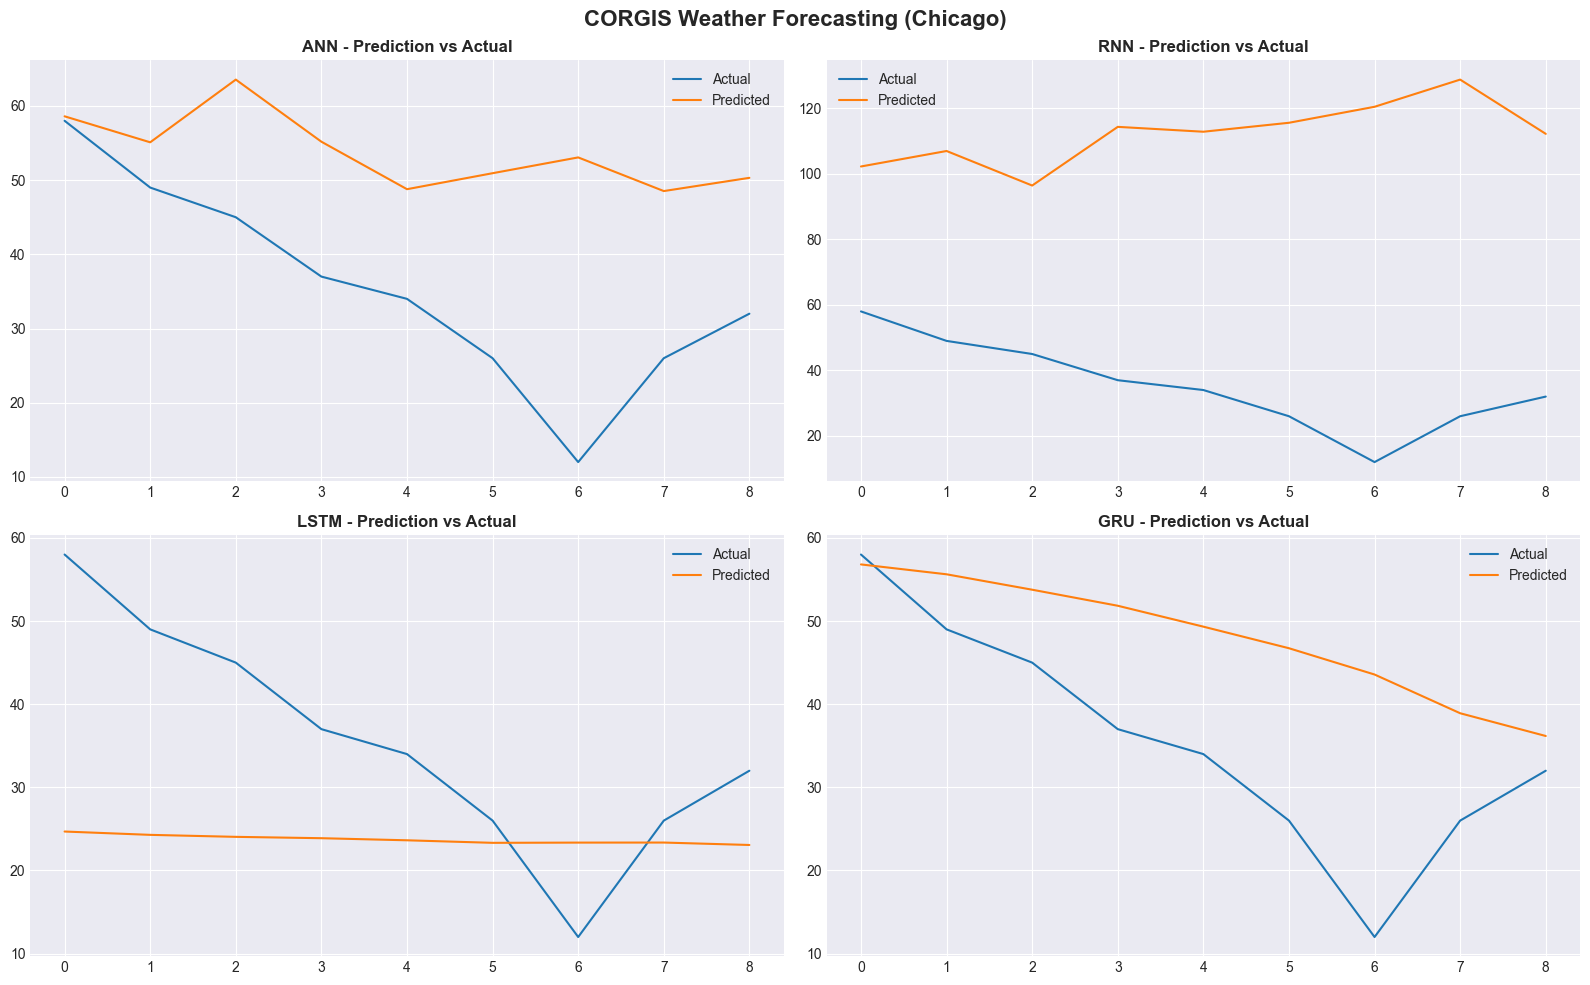


MODEL COMPARISON TABLE
          RMSE      MAE       R²
Model                           
ANN    21.2951  18.3388  -1.6706
RNN    79.5564  76.7736 -36.2740
LSTM   17.1982  14.2294  -0.7419
GRU    15.5910  12.9035  -0.4315


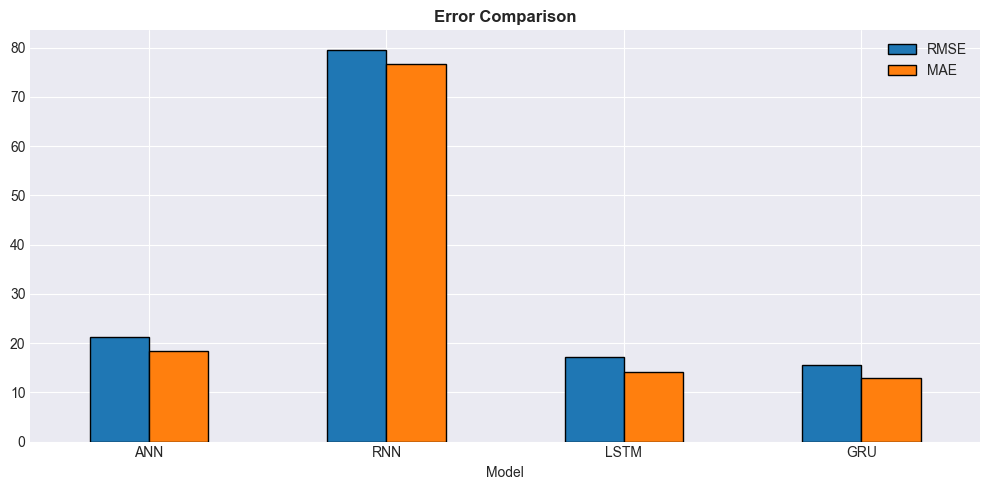


🏆 Best model: GRU (R² = -0.4315)

COMPARATIVE ANALYSIS:
- The CORGIS dataset has weekly granularity with many stations.
- Focusing on a single city provides clean temporal patterns.
- LSTM/GRU gates help capture seasonal temperature patterns.
- ANN treats all timestep features independently (no temporal awareness).
- GRU often matches LSTM with fewer parameters and faster training.



In [12]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, r in enumerate(results):
    ax = axes[i // 2, i % 2]
    ax.plot(r['y_actual'], label='Actual', linewidth=1.5)
    ax.plot(r['y_pred'], label='Predicted', linewidth=1.5)
    ax.set_title(f"{r['Model']} - Prediction vs Actual", fontweight='bold')
    ax.legend()
plt.suptitle(f'CORGIS Weather Forecasting ({city})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('corgis_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

comp_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_actual']}
                        for r in results]).set_index('Model')
print("\n" + "=" * 50)
print("MODEL COMPARISON TABLE")
print("=" * 50)
print(comp_df.round(4))

comp_df[['RMSE', 'MAE']].plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Error Comparison', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('corgis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = comp_df['R²'].idxmax()
print(f"\n🏆 Best model: {best} (R² = {comp_df.loc[best, 'R²']:.4f})")

print("""
COMPARATIVE ANALYSIS:
- The CORGIS dataset has weekly granularity with many stations.
- Focusing on a single city provides clean temporal patterns.
- LSTM/GRU gates help capture seasonal temperature patterns.
- ANN treats all timestep features independently (no temporal awareness).
- GRU often matches LSTM with fewer parameters and faster training.
""")


---
## 8. 💾 Model Saving

In [13]:

os.makedirs('saved_models', exist_ok=True)
model_ann.save('saved_models/corgis_ann_model.keras')
model_rnn.save('saved_models/corgis_rnn_model.keras')
model_lstm.save('saved_models/corgis_lstm_model.keras')
model_gru.save('saved_models/corgis_gru_model.keras')

with open('saved_models/corgis_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('saved_models/corgis_config.pkl', 'wb') as f:
    pickle.dump({'window_size': WINDOW_SIZE, 'feature_cols': feature_cols, 'target_idx': target_idx, 'city': city}, f)

comp_df.to_csv('saved_models/corgis_comparison_results.csv')
print("✅ All models saved! 🎉 CORGIS Weather Notebook Complete!")


✅ All models saved! 🎉 CORGIS Weather Notebook Complete!
